## Bài 1: Xây dựng mô hình Học máy dự đoán khả năng mua xe oto.

#### 1. Import libs

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-pastel")
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score, auc, average_precision_score, recall_score

np.random.seed(42)

In [201]:
def loadScores(f1, accuracy, precision, recall):
    return {
    "f1": f1,
    "recall": recall,
    "precision": precision,
    "accuracy": accuracy,
    }

#### 2. Prepare data

In [202]:
data = pd.read_csv("./Social_Network_Ads.csv")
data.head(3)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


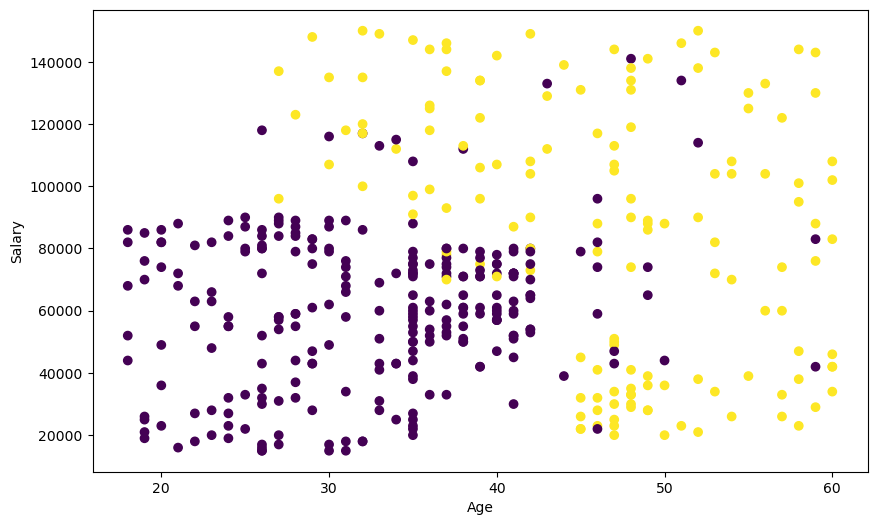

In [203]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(data["Age"], data["EstimatedSalary"], c=data["Purchased"])
ax.set(
    xlabel = "Age",
    ylabel="Salary"
)
fig.savefig("age-salary-scatter.png")

In [204]:
data.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [205]:
X = data.drop(["User ID", "Purchased"], axis=1) # UserID is irrelevant
Y = data["Purchased"]

In [206]:
# Non-numerical -> Numerical
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorial_features = ["Gender"]

one_hot = OneHotEncoder()
transformer = ColumnTransformer(
    [
        (
        "one_hot", # Name of transform
        one_hot, # Tranformer to use
        categorial_features # Which col to apply tranformer to
        )
    ], 
    remainder="passthrough", # Remaining
    sparse_threshold=0)


In [207]:
X_transformed = transformer.fit_transform(X)
X_transformed

array([[0.0e+00, 1.0e+00, 1.9e+01, 1.9e+04],
       [0.0e+00, 1.0e+00, 3.5e+01, 2.0e+04],
       [1.0e+00, 0.0e+00, 2.6e+01, 4.3e+04],
       ...,
       [1.0e+00, 0.0e+00, 5.0e+01, 2.0e+04],
       [0.0e+00, 1.0e+00, 3.6e+01, 3.3e+04],
       [1.0e+00, 0.0e+00, 4.9e+01, 3.6e+04]], shape=(400, 4))

In [208]:
pd.DataFrame(X_transformed).head(3)

,0,1,2,3
0,0.0,1.0,19.0,19000.0
1,0.0,1.0,35.0,20000.0
2,1.0,0.0,26.0,43000.0


### All features

In [209]:
# Split train-test sets
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_transformed, Y, train_size=0.8)

#### RandomForestClassifier

In [210]:
rfc = RandomForestClassifier()
rfc_untwisted = rfc.fit(X_train, Y_train)
rfc_untwisted_predictions = rfc_untwisted.predict(X_test)
rfc_untwisted_predictions

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [211]:
rfc_untwisted_f1 = f1_score(Y_test, rfc_untwisted_predictions)
rfc_untwisted_recall = recall_score(Y_test, rfc_untwisted_predictions)
rfc_untwisted_precision = average_precision_score(Y_test, rfc_untwisted_predictions)
rfc_untwisted_accuracy = accuracy_score(Y_test, rfc_untwisted_predictions)

rfc_untwisted_scores = loadScores(rfc_untwisted_f1, rfc_untwisted_accuracy, rfc_untwisted_precision, rfc_untwisted_recall)
rfc_untwisted_scores

{'f1': 0.8421052631578947,
 'recall': 0.8571428571428571,
 'precision': 0.75935960591133,
 'accuracy': 0.8875}

#### Logistic Regression

In [212]:
lrm = LogisticRegression()
lrm_untwisted = lrm.fit(X_train, Y_train)
lrm_untwisted_predictions = lrm_untwisted.predict(X_test)
lrm_untwisted_predictions

d:\learning\ml\ztm\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [213]:
lrm_untwisted_f1 = f1_score(Y_test, lrm_untwisted_predictions)
lrm_untwisted_precision = average_precision_score(Y_test, lrm_untwisted_predictions)
lrm_untwisted_accuracy = accuracy_score(Y_test, lrm_untwisted_predictions)
lrm_untwisted_recall = recall_score(Y_test, lrm_untwisted_predictions)

lrm_untwisted_scores = loadScores(lrm_untwisted_f1, lrm_untwisted_accuracy, lrm_untwisted_precision, lrm_untwisted_recall)
lrm_untwisted_scores

{'f1': 0.8235294117647058,
 'recall': 0.75,
 'precision': 0.7722826086956521,
 'accuracy': 0.8875}

#### Decision Tree

In [214]:
dtm = DecisionTreeClassifier()
dtm_untwisted = dtm.fit(X_train, Y_train)
dtm_untwisted_predictions = dtm_untwisted.predict(X_test)
dtm_untwisted_predictions

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [215]:
dtm_untwisted_f1 = f1_score(Y_test, dtm_untwisted_predictions)
dtm_untwisted_precision = average_precision_score(Y_test, dtm_untwisted_predictions)
dtm_untwisted_accuracy = accuracy_score(Y_test, dtm_untwisted_predictions)
dtm_untwisted_recall = recall_score(Y_test, dtm_untwisted_predictions)

dtm_untwisted_scores = loadScores(dtm_untwisted_f1, dtm_untwisted_accuracy, dtm_untwisted_precision, dtm_untwisted_recall)
dtm_untwisted_scores

{'f1': 0.8,
 'recall': 0.7857142857142857,
 'precision': 0.7152116402116401,
 'accuracy': 0.8625}

#### Neural Network

In [216]:
np.array(Y_test)

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1])

In [217]:
nnc = MLPClassifier()
nnc_untwisted = nnc.fit(X_train, Y_train)
nnc_untwisted_predictions = nnc_untwisted.predict(X_test)
nnc_untwisted_predictions

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [218]:
nnc_untwisted_f1 = f1_score(Y_test, nnc_untwisted_predictions)
nnc_untwisted_precision = average_precision_score(Y_test, nnc_untwisted_predictions)
nnc_untwisted_accuracy = accuracy_score(Y_test, nnc_untwisted_predictions)
nnc_untwisted_recall = recall_score(Y_test, nnc_untwisted_predictions)

nnc_untwisted_scores = loadScores(nnc_untwisted_f1, nnc_untwisted_accuracy, nnc_untwisted_precision, nnc_untwisted_recall)
nnc_untwisted_scores

{'f1': 0.5185185185185185, 'recall': 1.0, 'precision': 0.35, 'accuracy': 0.35}

#### Plotting

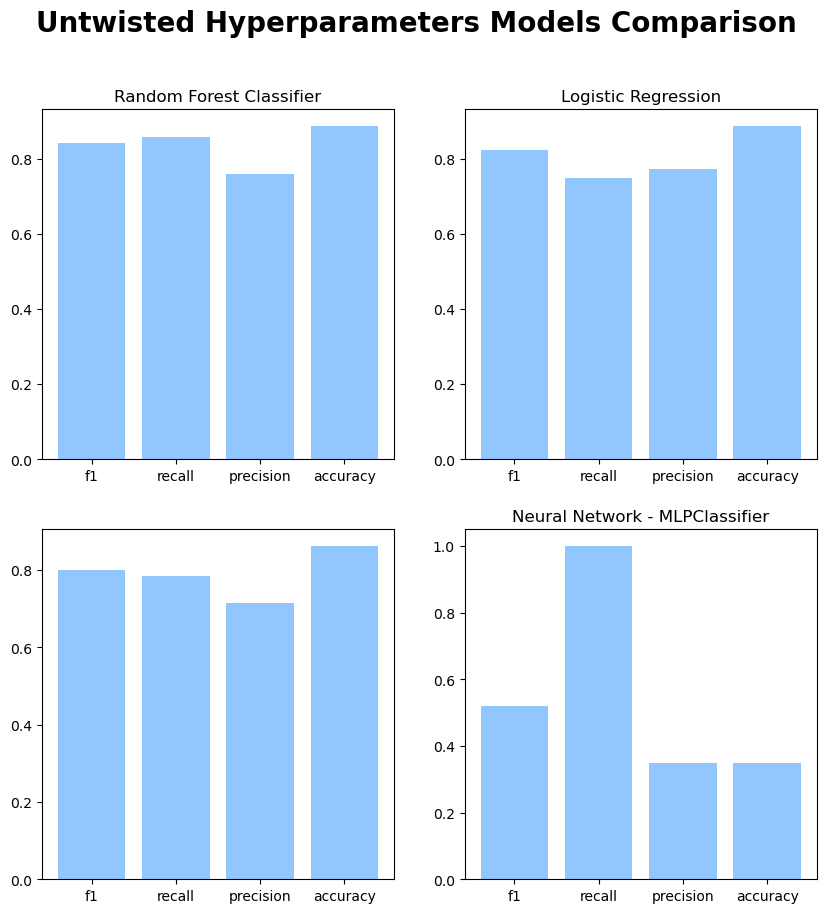

In [219]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
fig.suptitle(
    "Untwisted Hyperparameters Models Comparison", fontweight='bold', fontsize=20 
)
ax1.bar(rfc_untwisted_scores.keys(), rfc_untwisted_scores.values())
ax1.set(
    title="Random Forest Classifier",
)
ax2.bar(lrm_untwisted_scores.keys(), lrm_untwisted_scores.values())
ax2.set(
    title="Logistic Regression",
)
ax3.bar(dtm_untwisted_scores.keys(), dtm_untwisted_scores.values())
ax4.set(
    title="Decision Tree",
)
ax4.bar(nnc_untwisted_scores.keys(), nnc_untwisted_scores.values())
ax4.set(
    title="Neural Network - MLPClassifier",
)
fig.savefig("Untwisted Hyperparameters Models Comparison.png")

### Try dropping age feature

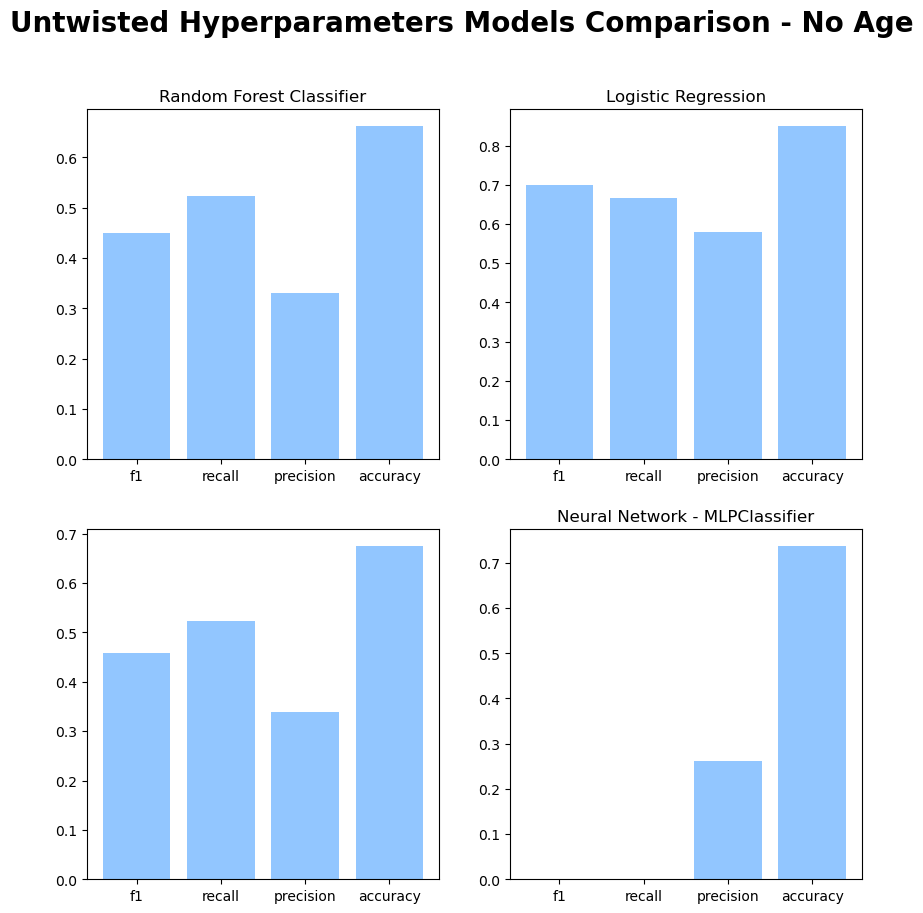

In [226]:
X_dropped_age = pd.DataFrame(X_transformed).drop(2,axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X_dropped_age, Y, train_size=0.8)

# Random Forest
rfc = RandomForestClassifier()
rfc_no_age = rfc.fit(X_train, Y_train)
rfc_no_age_predictions = rfc_no_age.predict(X_test)
rfc_no_age_f1 = f1_score(Y_test, rfc_no_age_predictions)
rfc_no_age_recall = recall_score(Y_test, rfc_no_age_predictions)
rfc_no_age_precision = average_precision_score(Y_test, rfc_no_age_predictions)
rfc_no_age_accuracy = accuracy_score(Y_test, rfc_no_age_predictions)
rfc_no_age_scores = loadScores(rfc_no_age_f1, rfc_no_age_accuracy, rfc_no_age_precision, rfc_no_age_recall)

# Logistic Regression
lrm = LogisticRegression()
lrm_no_age = lrm.fit(X_train, Y_train)
lrm_no_age_predictions = lrm_no_age.predict(X_test)
lrm_no_age_f1 = f1_score(Y_test, lrm_no_age_predictions)
lrm_no_age_precision = average_precision_score(Y_test, lrm_no_age_predictions)
lrm_no_age_accuracy = accuracy_score(Y_test, lrm_no_age_predictions)
lrm_no_age_recall = recall_score(Y_test, lrm_no_age_predictions)
lrm_no_age_scores = loadScores(lrm_no_age_f1, lrm_no_age_accuracy, lrm_no_age_precision, lrm_no_age_recall)

# Decision Tree
dtm = DecisionTreeClassifier()
dtm_no_age = dtm.fit(X_train, Y_train)
dtm_no_age_predictions = dtm_no_age.predict(X_test)
dtm_no_age_f1 = f1_score(Y_test, dtm_no_age_predictions)
dtm_no_age_precision = average_precision_score(Y_test, dtm_no_age_predictions)
dtm_no_age_accuracy = accuracy_score(Y_test, dtm_no_age_predictions)
dtm_no_age_recall = recall_score(Y_test, dtm_no_age_predictions)
dtm_no_age_scores = loadScores(dtm_no_age_f1, dtm_no_age_accuracy, dtm_no_age_precision, dtm_no_age_recall)

# Neural Network
nnc = MLPClassifier()
nnc_no_age = nnc.fit(X_train, Y_train)
nnc_no_age_predictions = nnc_no_age.predict(X_test)
nnc_no_age_f1 = f1_score(Y_test, nnc_no_age_predictions)
nnc_no_age_precision = average_precision_score(Y_test, nnc_no_age_predictions)
nnc_no_age_accuracy = accuracy_score(Y_test, nnc_no_age_predictions)
nnc_no_age_recall = recall_score(Y_test, nnc_no_age_predictions)
nnc_no_age_scores = loadScores(nnc_no_age_f1, nnc_no_age_accuracy, nnc_no_age_precision, nnc_no_age_recall)

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
fig.suptitle(
    "Untwisted Hyperparameters Models Comparison - No Age", fontweight='bold', fontsize=20 
)
ax1.bar(rfc_no_age_scores.keys(), rfc_no_age_scores.values())
ax1.set(
    title="Random Forest Classifier",
)
ax2.bar(lrm_no_age_scores.keys(), lrm_no_age_scores.values())
ax2.set(
    title="Logistic Regression",
)
ax3.bar(dtm_no_age_scores.keys(), dtm_no_age_scores.values())
ax4.set(
    title="Decision Tree",
)
ax4.bar(nnc_no_age_scores.keys(), nnc_no_age_scores.values())
ax4.set(
    title="Neural Network - MLPClassifier",
)
fig.savefig("Untwisted Hyperparameters Models Comparison - No Age.png")

### Try Dropping Gender Feature

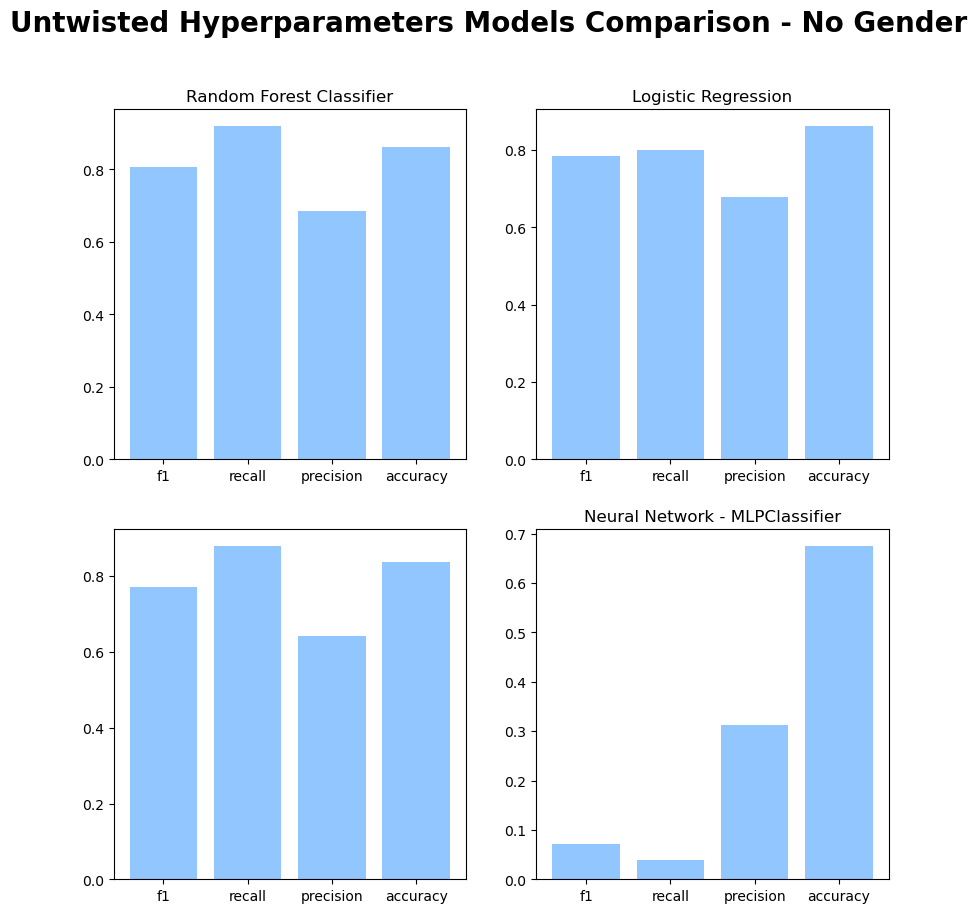

In [221]:
X_dropped_gender = pd.DataFrame(X_transformed).drop([0, 1], axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X_dropped_gender, Y, train_size=0.8)

# Random Forest
rfc = RandomForestClassifier()
rfc_no_gender = rfc.fit(X_train, Y_train)
rfc_no_gender_predictions = rfc_no_gender.predict(X_test)
rfc_no_gender_f1 = f1_score(Y_test, rfc_no_gender_predictions)
rfc_no_gender_recall = recall_score(Y_test, rfc_no_gender_predictions)
rfc_no_gender_precision = average_precision_score(Y_test, rfc_no_gender_predictions)
rfc_no_gender_accuracy = accuracy_score(Y_test, rfc_no_gender_predictions)
rfc_no_gender_scores = loadScores(rfc_no_gender_f1, rfc_no_gender_accuracy, rfc_no_gender_precision, rfc_no_gender_recall)

# Logistic Regression
lrm = LogisticRegression()
lrm_no_gender = lrm.fit(X_train, Y_train)
lrm_no_gender_predictions = lrm_no_gender.predict(X_test)
lrm_no_gender_f1 = f1_score(Y_test, lrm_no_gender_predictions)
lrm_no_gender_precision = average_precision_score(Y_test, lrm_no_gender_predictions)
lrm_no_gender_accuracy = accuracy_score(Y_test, lrm_no_gender_predictions)
lrm_no_gender_recall = recall_score(Y_test, lrm_no_gender_predictions)
lrm_no_gender_scores = loadScores(lrm_no_gender_f1, lrm_no_gender_accuracy, lrm_no_gender_precision, lrm_no_gender_recall)

# Decision Tree
dtm = DecisionTreeClassifier()
dtm_no_gender = dtm.fit(X_train, Y_train)
dtm_no_gender_predictions = dtm_no_gender.predict(X_test)
dtm_no_gender_f1 = f1_score(Y_test, dtm_no_gender_predictions)
dtm_no_gender_precision = average_precision_score(Y_test, dtm_no_gender_predictions)
dtm_no_gender_accuracy = accuracy_score(Y_test, dtm_no_gender_predictions)
dtm_no_gender_recall = recall_score(Y_test, dtm_no_gender_predictions)
dtm_no_gender_scores = loadScores(dtm_no_gender_f1, dtm_no_gender_accuracy, dtm_no_gender_precision, dtm_no_gender_recall)

# Neural Network
nnc = MLPClassifier()
nnc_no_gender = nnc.fit(X_train, Y_train)
nnc_no_gender_predictions = nnc_no_gender.predict(X_test)
nnc_no_gender_f1 = f1_score(Y_test, nnc_no_gender_predictions)
nnc_no_gender_precision = average_precision_score(Y_test, nnc_no_gender_predictions)
nnc_no_gender_accuracy = accuracy_score(Y_test, nnc_no_gender_predictions)
nnc_no_gender_recall = recall_score(Y_test, nnc_no_gender_predictions)
nnc_no_gender_scores = loadScores(nnc_no_gender_f1, nnc_no_gender_accuracy, nnc_no_gender_precision, nnc_no_gender_recall)

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
fig.suptitle(
    "Untwisted Hyperparameters Models Comparison - No Gender", fontweight='bold', fontsize=20 
)
ax1.bar(rfc_no_gender_scores.keys(), rfc_no_gender_scores.values())
ax1.set(
    title="Random Forest Classifier",
)
ax2.bar(lrm_no_gender_scores.keys(), lrm_no_gender_scores.values())
ax2.set(
    title="Logistic Regression",
)
ax3.bar(dtm_no_gender_scores.keys(), dtm_no_gender_scores.values())
ax4.set(
    title="Decision Tree",
)
ax4.bar(nnc_no_gender_scores.keys(), nnc_no_gender_scores.values())
ax4.set(
    title="Neural Network - MLPClassifier",
)
fig.savefig("Untwisted Hyperparameters Models Comparison - No Gender.png")

### Try Dropping Salary Features

d:\learning\ml\ztm\env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


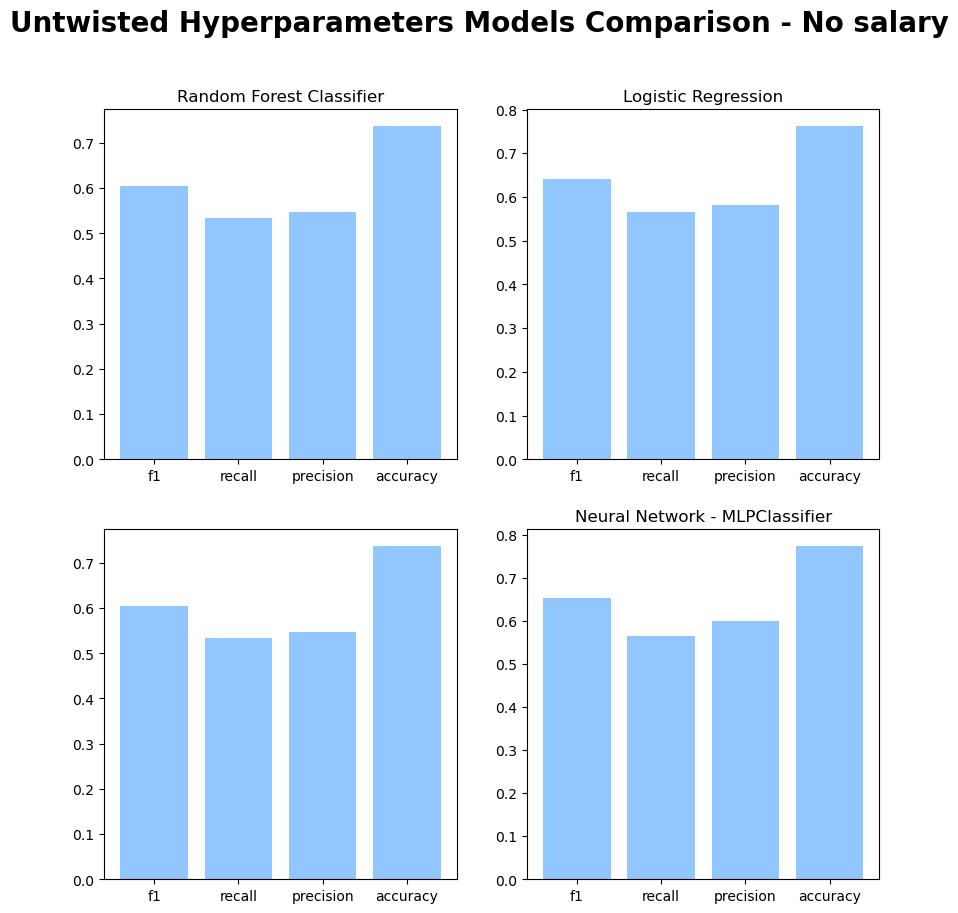

In [230]:
X_dropped_salary = pd.DataFrame(X_transformed).drop(3, axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X_dropped_salary, Y, train_size=0.8)

# Random Forest
rfc = RandomForestClassifier()
rfc_no_salary = rfc.fit(X_train, Y_train)
rfc_no_salary_predictions = rfc_no_salary.predict(X_test)
rfc_no_salary_f1 = f1_score(Y_test, rfc_no_salary_predictions)
rfc_no_salary_recall = recall_score(Y_test, rfc_no_salary_predictions)
rfc_no_salary_precision = average_precision_score(Y_test, rfc_no_salary_predictions)
rfc_no_salary_accuracy = accuracy_score(Y_test, rfc_no_salary_predictions)
rfc_no_salary_scores = loadScores(rfc_no_salary_f1, rfc_no_salary_accuracy, rfc_no_salary_precision, rfc_no_salary_recall)

# Logistic Regression
lrm = LogisticRegression()
lrm_no_salary = lrm.fit(X_train, Y_train)
lrm_no_salary_predictions = lrm_no_salary.predict(X_test)
lrm_no_salary_f1 = f1_score(Y_test, lrm_no_salary_predictions)
lrm_no_salary_precision = average_precision_score(Y_test, lrm_no_salary_predictions)
lrm_no_salary_accuracy = accuracy_score(Y_test, lrm_no_salary_predictions)
lrm_no_salary_recall = recall_score(Y_test, lrm_no_salary_predictions)
lrm_no_salary_scores = loadScores(lrm_no_salary_f1, lrm_no_salary_accuracy, lrm_no_salary_precision, lrm_no_salary_recall)

# Decision Tree
dtm = DecisionTreeClassifier()
dtm_no_salary = dtm.fit(X_train, Y_train)
dtm_no_salary_predictions = dtm_no_salary.predict(X_test)
dtm_no_salary_f1 = f1_score(Y_test, dtm_no_salary_predictions)
dtm_no_salary_precision = average_precision_score(Y_test, dtm_no_salary_predictions)
dtm_no_salary_accuracy = accuracy_score(Y_test, dtm_no_salary_predictions)
dtm_no_salary_recall = recall_score(Y_test, dtm_no_salary_predictions)
dtm_no_salary_scores = loadScores(dtm_no_salary_f1, dtm_no_salary_accuracy, dtm_no_salary_precision, dtm_no_salary_recall)

# Neural Network
nnc = MLPClassifier()
nnc_no_salary = nnc.fit(X_train, Y_train)
nnc_no_salary_predictions = nnc_no_salary.predict(X_test)
nnc_no_salary_f1 = f1_score(Y_test, nnc_no_salary_predictions)
nnc_no_salary_precision = average_precision_score(Y_test, nnc_no_salary_predictions)
nnc_no_salary_accuracy = accuracy_score(Y_test, nnc_no_salary_predictions)
nnc_no_salary_recall = recall_score(Y_test, nnc_no_salary_predictions)
nnc_no_salary_scores = loadScores(nnc_no_salary_f1, nnc_no_salary_accuracy, nnc_no_salary_precision, nnc_no_salary_recall)

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
fig.suptitle(
    "Untwisted Hyperparameters Models Comparison - No salary", fontweight='bold', fontsize=20 
)
ax1.bar(rfc_no_salary_scores.keys(), rfc_no_salary_scores.values())
ax1.set(
    title="Random Forest Classifier",
)
ax2.bar(lrm_no_salary_scores.keys(), lrm_no_salary_scores.values())
ax2.set(
    title="Logistic Regression",
)
ax3.bar(dtm_no_salary_scores.keys(), dtm_no_salary_scores.values())
ax4.set(
    title="Decision Tree",
)
ax4.bar(nnc_no_salary_scores.keys(), nnc_no_salary_scores.values())
ax4.set(
    title="Neural Network - MLPClassifier",
)
fig.savefig("Untwisted Hyperparameters Models Comparison - No salary.png")